## Ranking model: predicting which stocks should be ranked highest each day

In this section, I build a ranking model that orders stocks from the most promising
to the least promising in terms of next-day price gain.

I use a pointwise ranking approach:
- first, train one generic model to predict next-day price gain
- then, for each date, sort stocks by predicted gain in descending order


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from pathlib import Path
from sklearn.model_selection import ParameterGrid
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
data_path = Path("../01_data/raw/df_eda.csv")
df_model = pd.read_csv(data_path)

preview_cols = ["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]
print("Shape:", df_model.shape)
df_model[preview_cols].head()


Shape: (40351, 17)


,Date,Ticker,Open,High,Low,Close,Volume
0,2010-01-04,AAPL,7.622500,7.660714,7.585000,7.643214,493729600
1,2010-01-05,AAPL,7.664286,7.699643,7.616071,7.656429,601904800
2,2010-01-06,AAPL,7.656429,7.686786,7.526786,7.534643,552160000
3,2010-01-07,AAPL,7.562500,7.571429,7.466071,7.520714,477131200
4,2010-01-08,AAPL,7.510714,7.571429,7.466429,7.570714,447610800


The ranking target is next-day price gain, so the ranking reflects which stock is
expected to add the largest absolute price increase the following day.


In [3]:
ranking_df = df_model.copy()

ranking_df["Date"] = pd.to_datetime(ranking_df["Date"])
ranking_df = ranking_df.sort_values(["Date", "Ticker"]).reset_index(drop=True)

ranking_df["Target_Price_Gain_1d"] = ranking_df.groupby("Ticker")["Close"].shift(-1) - ranking_df["Close"]
ranking_df["Close_Change_1d"] = ranking_df.groupby("Ticker")["Close"].diff(1)

target_col = "Target_Price_Gain_1d"

candidate_numeric_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Close_Change_1d",
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volatility_20d",
    "Volume_Change_1d"
]

candidate_categorical_features = ["Ticker", "Weekday", "Month"]

numeric_features = [col for col in candidate_numeric_features if col in ranking_df.columns]
categorical_features = [col for col in candidate_categorical_features if col in ranking_df.columns]

# avoid duplicate Ticker column
feature_categorical_features = [col for col in categorical_features if col != "Ticker"]

required_cols = ["Date", "Ticker", target_col] + numeric_features + feature_categorical_features
ranking_df = ranking_df[required_cols].copy()

ranking_df = ranking_df.dropna(subset=[target_col]).copy()

# Keep only dates with at least 2 stocks available
valid_dates = (
    ranking_df.groupby("Date")["Ticker"]
    .nunique()
    .loc[lambda s: s >= 2]
    .index
)

ranking_df = ranking_df[ranking_df["Date"].isin(valid_dates)].copy()

ranking_df["Actual_Rank"] = (
    ranking_df.groupby("Date")[target_col]
    .rank(method="first", ascending=False)
)

print("Shape:", ranking_df.shape)
print("Number of ranking dates:", ranking_df["Date"].nunique())
ranking_df.head()


Shape: (40341, 18)
Number of ranking dates: 4094


,Date,Ticker,Target_Price_Gain_1d,Open,High,Low,Close,Volume,Close_Change_1d,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Weekday,Month,Actual_Rank
0,2010-01-04,AAPL,0.013215,7.622500,7.660714,7.585000,7.643214,493729600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monday,January,6.0
1,2010-01-04,AMZN,0.039500,6.812500,6.830500,6.657000,6.695000,151998000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monday,January,4.0
2,2010-01-04,GOOGL,-0.069069,15.689439,15.753504,15.621622,15.684434,78169752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monday,January,8.0
3,2010-01-04,HD,0.209999,29.150000,29.150000,28.549999,28.670000,13120900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monday,January,3.0
4,2010-01-04,JNJ,-0.750000,64.709999,64.989998,64.410004,64.680000,9506200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monday,January,9.0


The ranking dataset contains **40,341 observations across 4,094 trading dates**.
Each row represents one stock on one date, while `Actual_Rank` shows the true daily
ordering based on next-day price gain.


### Time-based train

Because this is financial time-series data, I split by time rather than randomly.  
This avoids leakage from the future into the past and makes the ranking task\
closer to a real forecasting setup.

In [4]:
unique_dates = np.array(sorted(ranking_df["Date"].unique()))

n_dates = len(unique_dates)
train_cut = int(n_dates * 0.70)
val_cut = int(n_dates * 0.85)

train_dates = unique_dates[:train_cut]
val_dates = unique_dates[train_cut:val_cut]
test_dates = unique_dates[val_cut:]

train_df = ranking_df[ranking_df["Date"].isin(train_dates)].copy()
val_df = ranking_df[ranking_df["Date"].isin(val_dates)].copy()
test_df = ranking_df[ranking_df["Date"].isin(test_dates)].copy()

for name, part in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(
        f"{name}: {part['Date'].min().date()} -> {part['Date'].max().date()} | "
        f"rows={len(part)} | dates={part['Date'].nunique()}"
    )

Train: 2010-01-04 -> 2021-05-20 | rows=28051 | dates=2865
Validation: 2021-05-21 -> 2023-10-27 | rows=6140 | dates=614
Test: 2023-10-30 -> 2026-04-14 | rows=6150 | dates=615


I will use:
- training set for fitting the models
- validation set for model selection
- test set for final evaluation

### Ranking

During ranking what matters is whether the model places the best opportunities near the top.

I use three ranking-oriented metrics:
- **NDCG@3**: checks whether the best stocks are placed near the top 3 positions
- **Spearman correlation**: measures how well the predicted order matches the true order
- **Top-1 hit rate**: shows how often the model correctly identifies the single best stock of the day

In [5]:
def dcg_at_k(relevance, k):
    relevance = np.asarray(relevance)[:k]
    if len(relevance) == 0:
        return np.nan
    discounts = np.log2(np.arange(2, len(relevance) + 2))
    return np.sum((2**relevance - 1) / discounts)


def evaluate_ranking(df, score_col, target_col="Target_Price_Gain_1d", k=3):
    daily_rows = []

    for date, g in df.groupby("Date"):
        g = g.dropna(subset=[score_col, target_col]).copy()

        if len(g) < 2:
            continue

        g = g.sort_values(score_col, ascending=False).reset_index(drop=True)
        n = len(g)

        # Convert actual ranks into positive relevance scores for NDCG
        actual_rank = g[target_col].rank(method="first", ascending=False)
        relevance = (n - actual_rank + 1).astype(int).to_numpy()

        dcg = dcg_at_k(relevance, min(k, n))
        idcg = dcg_at_k(np.sort(relevance)[::-1], min(k, n))
        ndcg = dcg / idcg if idcg > 0 else np.nan

        spearman = g[[score_col, target_col]].corr(method="spearman").iloc[0, 1]

        predicted_top = g.iloc[0]["Ticker"]
        actual_top = g.loc[g[target_col].idxmax(), "Ticker"]
        top1_hit = int(predicted_top == actual_top)

        daily_rows.append({
            "Date": date,
            "NDCG@3": ndcg,
            "Spearman": spearman,
            "Top1_Hit": top1_hit,
            "Predicted_Top1": predicted_top,
            "Actual_Top1": actual_top,
            "Top1_Actual_Gain": g.iloc[0][target_col],
            "Best_Actual_Gain": g[target_col].max(),
            "Universe_Mean_Gain": g[target_col].mean()
        })

    daily_eval = pd.DataFrame(daily_rows)

    summary = pd.DataFrame({
        "Metric": ["NDCG@3", "Spearman", "Top1_Hit", "Top1_Actual_Gain", "Best_Actual_Gain", "Universe_Mean_Gain"],
        "Value": [
            daily_eval["NDCG@3"].mean(),
            daily_eval["Spearman"].mean(),
            daily_eval["Top1_Hit"].mean(),
            daily_eval["Top1_Actual_Gain"].mean(),
            daily_eval["Best_Actual_Gain"].mean(),
            daily_eval["Universe_Mean_Gain"].mean()
        ]
    })

    return daily_eval, summary


### 1st try

Before using machine learning, I create a simple benchmark:
rank stocks by today's `Close_Change_1d` (naive price momentum).

This baseline directly aligns with the requirement to rank by possible daily gains,
and gives a simple reference that the ML model should try to beat.


In [6]:
baseline_score_col = "Close_Change_1d"

val_baseline_daily, val_baseline_summary = evaluate_ranking(
    val_df,
    score_col=baseline_score_col,
    target_col=target_col
)

test_baseline_daily, test_baseline_summary = evaluate_ranking(
    test_df,
    score_col=baseline_score_col,
    target_col=target_col
)

print("Validation baseline:")
display(val_baseline_summary)

print("Test baseline:")
display(test_baseline_summary)


Validation baseline:


,Metric,Value
0,NDCG@3,0.307080
1,Spearman,-0.004542
2,Top1_Hit,0.131922
3,Top1_Actual_Gain,-0.073243
4,Best_Actual_Gain,4.336582
5,Universe_Mean_Gain,0.013111


Test baseline:


,Metric,Value
0,NDCG@3,0.332912
1,Spearman,0.006604
2,Top1_Hit,0.169106
3,Top1_Actual_Gain,0.087642
4,Best_Actual_Gain,7.205951
5,Universe_Mean_Gain,0.198740


The baseline ranks stocks by today's close-price change (`Close_Change_1d`).
Its ranking quality gives a simple reference point before machine learning models.


### 2nd try

I compare three pointwise models:
- **Linear Regression**: a simple linear benchmark
- **Random Forest**: captures nonlinear patterns and interactions
- **LightGBM**: usually well performing on tabular data

I keep the same feature set and preprocessing for all models so the comparison is fair.

I choose the final model based on validation ranking quality, not just on regression logic.

In [7]:
feature_cols = numeric_features + feature_categorical_features

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, feature_categorical_features)
])

preprocessor.set_output(transform="pandas")

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMRegressor was fitted with feature names"
)

param_grids = {
    "Linear Regression": [{}],
    "Random Forest": list(ParameterGrid({
        "n_estimators": [200, 300],
        "max_depth": [5, 10, None],
        "min_samples_leaf": [3, 5]
    })),
    "LightGBM": list(ParameterGrid({
        "n_estimators": [100, 300],
        "learning_rate": [0.03, 0.05, 0.1],
        "num_leaves": [15, 31],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }))
}

best_models = {}
all_tuning_results = []
validation_results = []

for model_name, grid in param_grids.items():
    best_row = None
    best_pipe = None
    best_score = -np.inf

    for params in grid:
        if model_name == "Linear Regression":
            model = LinearRegression()

        elif model_name == "Random Forest":
            model = RandomForestRegressor(
                random_state=42,
                n_jobs=-1,
                **params
            )

        elif model_name == "LightGBM":
            model = LGBMRegressor(
                objective="regression",
                random_state=42,
                verbose=-1,
                **params
            )

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipe.fit(train_df[feature_cols], train_df[target_col])

        val_scored = val_df.copy()
        val_scored["Predicted_Score"] = pipe.predict(val_df[feature_cols])

        _, val_summary = evaluate_ranking(
            val_scored,
            score_col="Predicted_Score",
            target_col=target_col
        )

        row = val_summary.set_index("Metric")["Value"].to_dict()
        row["Model"] = model_name
        row["Params"] = params
        all_tuning_results.append(row)

        current_score = row["NDCG@3"]

        if current_score > best_score:
            best_score = current_score
            best_row = row
            best_pipe = pipe

    validation_results.append(best_row)
    best_models[model_name] = {
        "pipeline": best_pipe,
        "params": best_row["Params"]
    }

validation_comparison = (
    pd.DataFrame(validation_results)
    .set_index("Model")
    .sort_values(["NDCG@3", "Top1_Hit", "Spearman"], ascending=False)
)

all_tuning_results_df = (
    pd.DataFrame(all_tuning_results)
    .sort_values(["NDCG@3", "Top1_Hit", "Spearman"], ascending=False)
    .reset_index(drop=True)
)

validation_comparison

,NDCG@3,Spearman,Top1_Hit,Top1_Actual_Gain,Best_Actual_Gain,Universe_Mean_Gain,Params
Model,,,,,,,
Linear Regression,0.330396,-0.023138,0.153094,0.116534,4.336582,0.013111,{}
Random Forest,0.330303,0.007058,0.151466,0.224896,4.336582,0.013111,"{'max_depth': 5, 'min_samples_leaf': 3, 'n_est..."
LightGBM,0.322445,-0.000824,0.143322,-0.213806,4.336582,0.013111,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."


After hyperparameter tuning, the selected final model is the one shown in the output
above (chosen by validation ranking quality, primarily NDCG@3).


## 3rd test

After choosing the strongest model on the validation set,\
I use it on both training and validation data.

In [8]:
best_model_name = validation_comparison.index[0]
best_model_params = best_models[best_model_name]["params"]

if best_model_name == "Linear Regression":
    final_estimator = LinearRegression()

elif best_model_name == "Random Forest":
    final_estimator = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **best_model_params
    )

elif best_model_name == "LightGBM":
    final_estimator = LGBMRegressor(
        objective="regression",
        random_state=42,
        verbose=-1,
        **best_model_params
    )

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_estimator)
])

train_val_df = pd.concat([train_df, val_df], axis=0).sort_values(["Date", "Ticker"])

final_model.fit(train_val_df[feature_cols], train_val_df[target_col])

test_scored = test_df.copy()
test_scored["Predicted_Score"] = final_model.predict(test_df[feature_cols])

test_model_daily, test_model_summary = evaluate_ranking(
    test_scored,
    score_col="Predicted_Score",
    target_col=target_col
)

print("Chosen model:", best_model_name)
print("Best params:", best_model_params)
display(test_model_summary)

Chosen model: Linear Regression
Best params: {}


,Metric,Value
0,NDCG@3,0.312810
1,Spearman,-0.021970
2,Top1_Hit,0.151220
3,Top1_Actual_Gain,0.295058
4,Best_Actual_Gain,7.205951
5,Universe_Mean_Gain,0.198740


The ranking model achieved **moderate NDCG@3**, but its **Spearman correlation is still close to zero**,\
which means the overall daily stock ordering remains difficult to predict. The model identifies the best\
stock of the day rarely, so ranking precision is still fairly weak.

## Compare models

This comparison shows whether the machine learning model improves:
- the overall ordering of stocks
- the quality of the top-ranked ideas
- the chance of correctly selecting the best stock of the day

In [9]:
comparison_df = pd.DataFrame({
    "Naive price momentum (Close_Change_1d)": test_baseline_summary.set_index("Metric")["Value"],
    f"Final model ({best_model_name})": test_model_summary.set_index("Metric")["Value"]
}).T

comparison_df


Metric,NDCG@3,Spearman,Top1_Hit,Top1_Actual_Gain,Best_Actual_Gain,Universe_Mean_Gain
Naive price momentum (Close_Change_1d),0.332912,0.006604,0.169106,0.087642,7.205951,0.19874
Final model (Linear Regression),0.312810,-0.021970,0.151220,0.295058,7.205951,0.19874


### Baseline vs final ranking model

This table compares the final model with a naive price-momentum baseline.
Focus on NDCG, Top1 hit rate, and realized top-pick **price gain** to judge ranking usefulness.


## Inspect one daily ranking example

Besides summary metrics, it is useful to look at one date directly.  
This makes it easier to see how the predicted ranking compares with the actual ranking.

In [10]:
sample_date = test_scored["Date"].drop_duplicates().iloc[0]

sample_ranking = (
    test_scored.loc[test_scored["Date"] == sample_date, ["Date", "Ticker", "Predicted_Score", target_col]]
    .sort_values("Predicted_Score", ascending=False)
    .reset_index(drop=True)
)

sample_ranking["Predicted_Rank"] = np.arange(1, len(sample_ranking) + 1)
sample_ranking["Actual_Rank"] = (
    sample_ranking[target_col]
    .rank(method="first", ascending=False)
    .astype(int)
)

sample_ranking

,Date,Ticker,Predicted_Score,Target_Price_Gain_1d,Predicted_Rank,Actual_Rank
0,2023-10-30,META,1.245425,-1.390015,1,10
1,2023-10-30,XOM,0.257909,-0.029999,2,8
2,2023-10-30,AAPL,0.178719,0.480011,3,6
3,2023-10-30,JNJ,0.122779,1.309998,4,3
4,2023-10-30,JPM,0.105165,1.639999,5,2
5,2023-10-30,GOOGL,0.100464,-0.379997,6,9
6,2023-10-30,PG,0.007690,0.770004,7,5
7,2023-10-30,HD,-0.025722,3.209991,8,1
8,2023-10-30,MSFT,-0.166819,0.799988,9,4
9,2023-10-30,AMZN,-0.503991,0.379990,10,7


## Visualize ranking performance

I use two plots:
- a bar chart for the main ranking metrics
- a rolling plot of realized next-day price gain from the top-ranked stock

These plots summarize ranking quality and practical top-pick behavior over time.


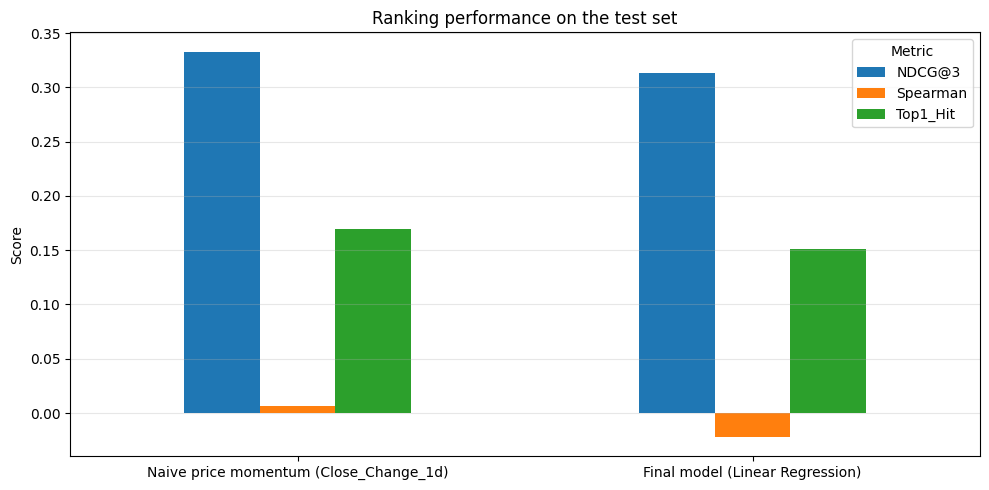

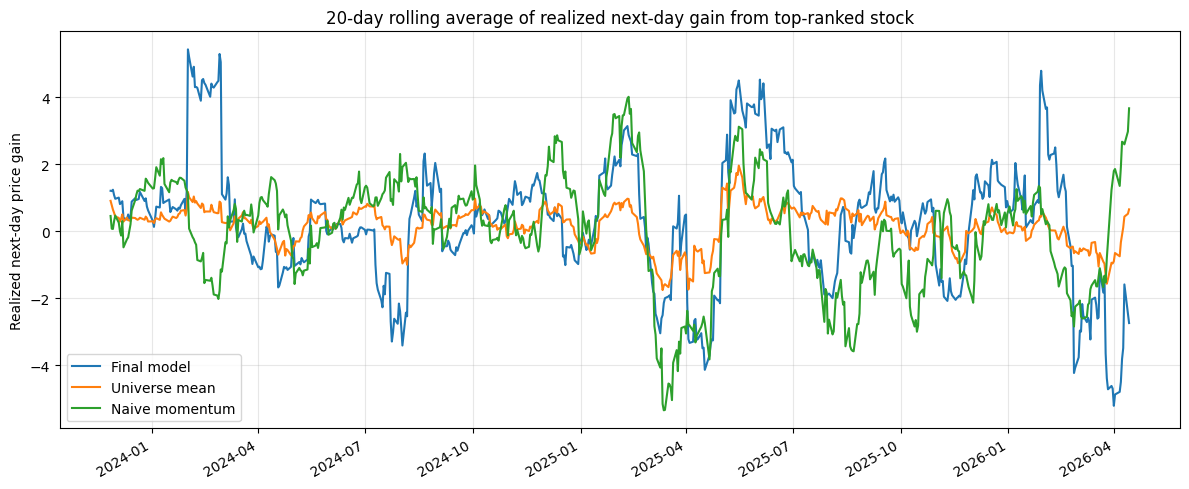

In [11]:
# Bar chart for key ranking metrics
plot_metrics = ["NDCG@3", "Spearman", "Top1_Hit"]

comparison_df[plot_metrics].plot(kind="bar", figsize=(10, 5))
plt.title("Ranking performance on the test set")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# Rolling realized gain of the top-ranked stock
baseline_plot = test_baseline_daily[["Date", "Top1_Actual_Gain"]].rename(
    columns={"Top1_Actual_Gain": "Naive momentum"}
)

model_plot = test_model_daily[["Date", "Top1_Actual_Gain", "Universe_Mean_Gain"]].rename(
    columns={
        "Top1_Actual_Gain": "Final model",
        "Universe_Mean_Gain": "Universe mean"
    }
)

rolling_plot_df = (
    model_plot.merge(baseline_plot, on="Date", how="inner")
    .sort_values("Date")
    .set_index("Date")
    .rolling(20)
    .mean()
)

rolling_plot_df.plot(figsize=(12, 5))
plt.title("20-day rolling average of realized next-day gain from top-ranked stock")
plt.ylabel("Realized next-day price gain")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Overview

In this notebook, I built a ranking framework that predicts next-day price gain and
then ranks stocks within each trading date from highest expected gain to lowest.
The pointwise setup converts regression predictions into daily rankings, evaluated
with NDCG@3, Spearman correlation, and Top-1 hit rate.

This gives a practical view of whether the model can place stronger gain opportunities
near the top of the list.
